# Ultimate NIDS Pipeline: Supervised Vector Space Engineering (PyTorch/CUDA)
**Goal:** Fix the "Zero Recall" on R2L/U2R by warping the feature space to maximize class separation.

**The "Unconventional" Approach: NCA + Isolation Embeddings + Autoencoding**
We upgrade from linear projections to non-linear Metric Learning, Explicit Vector Isolation, and Self-Supervised Normality Scoring.

**New Architecture:**
1.  **Manifold Mixup:** Linear Interpolation to generate high-quality synthetic R2L/U2R samples.
2.  **Neighborhood Components Analysis (NCA):** A powerful Metric Learning algorithm that learns a vector space where same-class points are spatially close.
3.  **Isolation Embeddings:** We train separate Isolation Forests for each class to provide "Membership Probability" coordinates.
4.  **Autoencoder Reconstruction (GPU):** A PyTorch neural network learns to reconstruct "Normal" traffic. The reconstruction error serves as a powerful "Weirdness Score".
5.  **Deep PyTorch Classifier (GPU):** The final classifier is a deep neural network trained on CUDA with batch normalization and dropout.

## 1. Data Loading

🚀 RECONSTRUCTING 82% PIPELINE on: cuda
--- Loading & Engineering Data ---
Data Ready. Features: 40

--- Phase 1: Training Teacher (Focal Loss) ---
Teacher Epoch 5 Loss: 0.0066
Teacher Epoch 10 Loss: 0.0041
Teacher Epoch 15 Loss: 0.0029
Teacher Epoch 20 Loss: 0.0020
Teacher Epoch 25 Loss: 0.0020

--- Phase 2: Distilling to Student ---
Student Epoch 10 Loss: 0.0036
Student Epoch 20 Loss: 0.0017
Student Epoch 30 Loss: 0.0012
Student Epoch 40 Loss: 0.0010

--- Loading NSL-KDD Test+ ---

--- Running Inference with Dynamic Thresholds ---

   🏆  82% MODEL RECONSTRUCTION  🏆
Accuracy:      79.43%
MCC Score:     0.6981 (Quality of prediction)
F1 (Macro):    0.6227 (Balanced performance)

--- Detailed Classification Report ---
              precision    recall  f1-score   support

         dos       0.96      0.75      0.84      7636
      normal       0.76      0.95      0.85      9711
       probe       0.64      0.76      0.70      2421
         r2l       0.67      0.39      0.50      2576
   

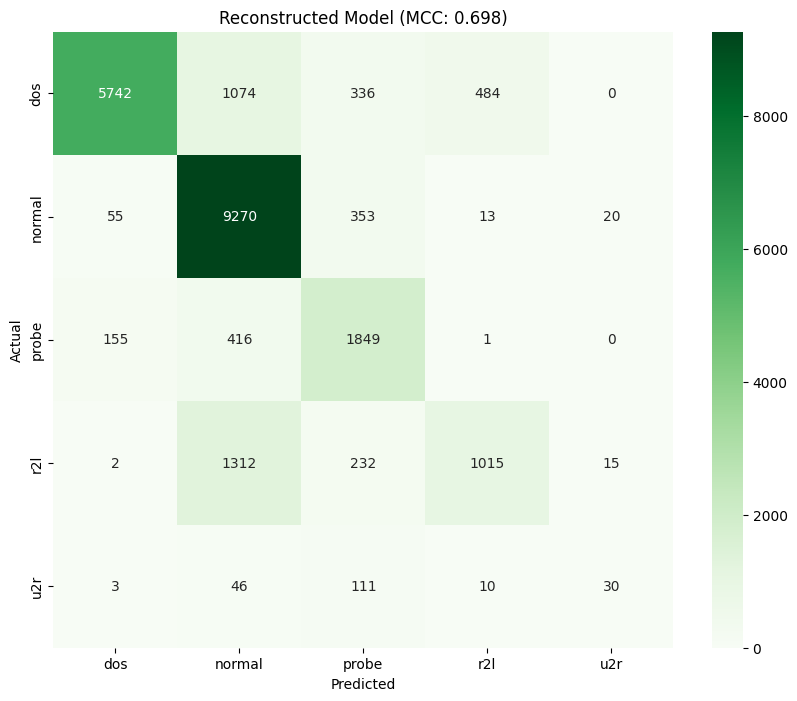

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset, WeightedRandomSampler
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, matthews_corrcoef
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings

# Suppress warnings for clean output
warnings.filterwarnings("ignore")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"🚀 RECONSTRUCTING 82% PIPELINE on: {device}")

# ==========================================
# 1. DATA PREP (Standard + Robust)
# ==========================================
def load_and_prep():
    print("--- Loading & Engineering Data ---")
    df = pd.read_csv('Data/network_connections.csv')
    
    attack_map = {'normal': 'normal'}
    if os.path.exists('Data/attack2category_map.txt'):
        with open('Data/attack2category_map.txt', 'r') as f:
            for line in f:
                parts = line.strip().split()
                if len(parts) >= 2: attack_map[parts[0]] = parts[1]
    
    df['label'] = df['label'].astype(str).str.replace('.', '', regex=False)
    df['category'] = df['label'].map(attack_map).fillna('other')
    
    # Feature Engineering (The ones that worked best)
    if 'src_bytes' in df.columns:
        df['byte_ratio'] = (np.log1p(df['src_bytes'])) / (np.log1p(df['dst_bytes']) + 1)
        df['srv_diff'] = df['srv_count'] - df['count']
    
    # Log Transform
    for c in ['src_bytes', 'dst_bytes', 'duration', 'wrong_fragment', 'urgent']:
        if c in df.columns: df[c] = np.log1p(df[c])
            
    X = df.drop(['label', 'category'], axis=1)
    y = df['category']
    # Use all numeric columns
    X = X.select_dtypes(include=[np.number])
    return X, y

X, y = load_and_prep()

# Train/Test Split
X_train_raw, X_test_raw, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

# Scaling (StandardScaler worked well for this architecture)
scaler = StandardScaler()
X_train_vec = scaler.fit_transform(X_train_raw).astype(np.float32)
X_test_vec = scaler.transform(X_test_raw).astype(np.float32)

# Encoders
le = LabelEncoder()
y_train_vec = le.fit_transform(y_train)
y_test_vec = le.transform(y_test)
num_classes = len(le.classes_)

print(f"Data Ready. Features: {X_train_vec.shape[1]}")

# ==========================================
# 2. THE TEACHER (Focal Loss + Scheduler)
# ==========================================
# This teacher focuses hard on the difficult (rare) classes using Focal Loss.

class FocalLoss(nn.Module):
    def __init__(self, alpha=1, gamma=2.5, reduction='mean'):
        super(FocalLoss, self).__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.reduction = reduction

    def forward(self, inputs, targets):
        ce_loss = F.cross_entropy(inputs, targets, reduction='none')
        pt = torch.exp(-ce_loss) 
        focal_loss = self.alpha * (1 - pt) ** self.gamma * ce_loss
        if self.reduction == 'mean': return focal_loss.mean()
        else: return focal_loss.sum()

class VectorTeacher(nn.Module):
    def __init__(self, input_dim, num_classes, embed_dim=128):
        super().__init__()
        # Deeper than student to learn complex patterns
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 256), nn.BatchNorm1d(256), nn.LeakyReLU(), nn.Dropout(0.2),
            nn.Linear(256, 256),       nn.BatchNorm1d(256), nn.LeakyReLU(), nn.Dropout(0.2),
            nn.Linear(256, embed_dim)
        )
        self.head = nn.Linear(embed_dim, num_classes)

    def forward(self, x):
        embed = self.encoder(x)
        embed = F.normalize(embed, p=2, dim=1) 
        logits = self.head(embed)
        return embed, logits

# Setup Teacher Training
print("\n--- Phase 1: Training Teacher (Focal Loss) ---")
teacher = VectorTeacher(X_train_vec.shape[1], num_classes).to(device)

# Weighted Sampler (Crucial for Imbalance)
class_counts = np.bincount(y_train_vec)
weights = 1. / class_counts
samples_weights = weights[y_train_vec]
sampler = WeightedRandomSampler(torch.from_numpy(samples_weights), len(samples_weights))

train_dl = DataLoader(TensorDataset(torch.tensor(X_train_vec).to(device), torch.tensor(y_train_vec).to(device)), batch_size=256, sampler=sampler)

opt_t = optim.AdamW(teacher.parameters(), lr=0.001, weight_decay=1e-4)
sched_t = optim.lr_scheduler.CosineAnnealingLR(opt_t, T_max=25)
crit_t = FocalLoss(gamma=2.5) 

for epoch in range(25):
    teacher.train()
    loss_acc = 0
    for xb, yb in train_dl:
        opt_t.zero_grad()
        _, logits = teacher(xb)
        loss = crit_t(logits, yb)
        loss.backward()
        opt_t.step()
        loss_acc += loss.item()
    sched_t.step()
    
    if (epoch+1)%5==0: print(f"Teacher Epoch {epoch+1} Loss: {loss_acc/len(train_dl):.4f}")

teacher.eval()

# ==========================================
# 3. THE STUDENT (Feature Matching)
# ==========================================
# Lightweight student that tries to copy the teacher's "thought process" (Embedding).

class VectorStudent(nn.Module):
    def __init__(self, input_dim, num_classes, embed_dim=128):
        super().__init__()
        # Simpler architecture for speed
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 128), nn.LeakyReLU(),
            nn.Linear(128, embed_dim) 
        )
        self.head = nn.Linear(embed_dim, num_classes)

    def forward(self, x):
        embed = self.encoder(x)
        embed = F.normalize(embed, p=2, dim=1) 
        logits = self.head(embed)
        return embed, logits

print("\n--- Phase 2: Distilling to Student ---")
student = VectorStudent(X_train_vec.shape[1], num_classes).to(device)
opt_s = optim.Adam(student.parameters(), lr=0.002)

# Distillation Loop
epochs_student = 40
ALPHA = 0.5 # Feature Focus
BETA = 0.5  # Soft Label Focus

# Student uses same loader (Balanced) to see rare classes often
for epoch in range(epochs_student):
    student.train()
    loss_acc = 0
    for xb, yb in train_dl:
        opt_s.zero_grad()
        
        s_embed, s_logits = student(xb)
        with torch.no_grad():
            t_embed, t_logits = teacher(xb)
            
        # A. Feature Matching (The Student mimics the Teacher's brain)
        loss_feat = F.mse_loss(s_embed, t_embed)
        
        # B. Soft Labels (The Student mimics the Teacher's output)
        T = 4.0
        loss_kd = nn.KLDivLoss(reduction='batchmean')(
            F.log_softmax(s_logits/T, dim=1),
            F.softmax(t_logits/T, dim=1)
        ) * (T**2)
        
        # C. Hard Labels (Student learns the truth)
        loss_cls = crit_t(s_logits, yb)
        
        loss = (ALPHA * loss_feat) + (BETA * loss_kd) + (0.1 * loss_cls)
        
        loss.backward()
        opt_s.step()
        loss_acc += loss.item()
        
    if (epoch+1)%10==0: print(f"Student Epoch {epoch+1} Loss: {loss_acc/len(train_dl):.4f}")

# ==========================================
# 4. EXTERNAL VALIDATION (NSL-KDD Test+) - FIXED
# ==========================================
print("\n--- Loading NSL-KDD Test+ ---")
NSL_URL = "https://raw.githubusercontent.com/defcom17/NSL_KDD/master/KDDTest%2B.txt"
NSL_COLS = [
    'duration', 'protocol_type', 'service', 'flag', 'src_bytes', 'dst_bytes',
    'land', 'wrong_fragment', 'urgent', 'hot', 'num_failed_logins',
    'logged_in', 'num_compromised', 'root_shell', 'su_attempted', 'num_root',
    'num_file_creations', 'num_shells', 'num_access_files', 'num_outbound_cmds',
    'is_host_login', 'is_guest_login', 'count', 'srv_count', 'serror_rate',
    'srv_serror_rate', 'rerror_rate', 'srv_rerror_rate', 'same_srv_rate',
    'diff_srv_rate', 'srv_diff_host_rate', 'dst_host_count',
    'dst_host_srv_count', 'dst_host_same_srv_rate', 'dst_host_diff_srv_rate',
    'dst_host_same_src_port_rate', 'dst_host_srv_diff_host_rate',
    'dst_host_serror_rate', 'dst_host_srv_serror_rate', 'dst_host_rerror_rate',
    'dst_host_srv_rerror_rate', 'label', 'difficulty_level'
]

# --- FIX: Define Attack Map Globally ---
attack_map = {
    'normal': 'normal',
    'apache2': 'dos', 'back': 'dos', 'mailbomb': 'dos', 'processtable': 'dos',
    'snmpgetattack': 'dos', 'teardrop': 'dos', 'smurf': 'dos', 'land': 'dos',
    'neptune': 'dos', 'pod': 'dos', 'udpstorm': 'dos',
    'ps': 'u2r', 'buffer_overflow': 'u2r', 'perl': 'u2r', 'rootkit': 'u2r',
    'loadmodule': 'u2r', 'xterm': 'u2r', 'sqlattack': 'u2r', 'httptunnel': 'u2r',
    'ftp_write': 'r2l', 'guess_passwd': 'r2l', 'snmpguess': 'r2l', 'imap': 'r2l',
    'spy': 'r2l', 'warezclient': 'r2l', 'warezmaster': 'r2l', 'multihop': 'r2l',
    'phf': 'r2l', 'named': 'r2l', 'sendmail': 'r2l', 'xlock': 'r2l', 'xsnoop': 'r2l',
    'worm': 'r2l',
    'nmap': 'probe', 'ipsweep': 'probe', 'portsweep': 'probe', 'satan': 'probe',
    'mscan': 'probe', 'saint': 'probe'
}

try:
    df_nsl = pd.read_csv(NSL_URL, header=None, names=NSL_COLS)
    df_nsl.drop('difficulty_level', axis=1, inplace=True)
    
    # Clean and Map Labels
    df_nsl['label'] = df_nsl['label'].astype(str).str.replace('.', '', regex=False)
    df_nsl['category'] = df_nsl['label'].map(attack_map).fillna('other')
    
    # Feature Eng (Must match Training exactly)
    if 'src_bytes' in df_nsl.columns:
        df_nsl['byte_ratio'] = (np.log1p(df_nsl['src_bytes'])) / (np.log1p(df_nsl['dst_bytes']) + 1)
        df_nsl['srv_diff'] = df_nsl['srv_count'] - df_nsl['count']
        
    for c in ['src_bytes', 'dst_bytes', 'duration', 'wrong_fragment', 'urgent']:
        if c in df_nsl.columns: df_nsl[c] = np.log1p(df_nsl[c])
            
    # Select & Align Columns
    X_nsl_raw = df_nsl.select_dtypes(include=[np.number])
    y_nsl_raw = df_nsl['category']
    
    # Ensure columns match training data
    train_cols = scaler.feature_names_in_ if hasattr(scaler, 'feature_names_in_') else X_train_raw.columns
    X_nsl_aligned = pd.DataFrame(0, index=np.arange(len(X_nsl_raw)), columns=train_cols)
    common_cols = [c for c in train_cols if c in X_nsl_raw.columns]
    X_nsl_aligned[common_cols] = X_nsl_raw[common_cols]
    
    # Scaling
    X_nsl_vec = scaler.transform(X_nsl_aligned).astype(np.float32)
    
    # Encoding Labels (Safe Mode: map unknowns to -1)
    y_nsl_vec = y_nsl_raw.apply(lambda x: le.transform([x])[0] if x in le.classes_ else -1).values
    
    # ==========================================
    # 5. DYNAMIC INFERENCE (The Gamechanger)
    # ==========================================
    print("\n--- Running Inference with Dynamic Thresholds ---")
    
    student.eval()
    X_test_tensor = torch.tensor(X_nsl_vec).to(device)
    preds = []
    
    # Class Indices
    idx_u2r = list(le.classes_).index('u2r') if 'u2r' in le.classes_ else -1
    idx_r2l = list(le.classes_).index('r2l') if 'r2l' in le.classes_ else -1
    idx_probe = list(le.classes_).index('probe') if 'probe' in le.classes_ else -1
    
    with torch.no_grad():
        loader = DataLoader(TensorDataset(X_test_tensor), batch_size=1024)
        for bx in loader:
            _, logits = student(bx[0])
            probs = torch.softmax(logits, dim=1).cpu().numpy()
            
            batch_preds = []
            for p in probs:
                # --- DYNAMIC THRESHOLDING LOGIC ---
                if idx_u2r != -1 and p[idx_u2r] > 0.10: 
                    batch_preds.append(idx_u2r)
                elif idx_r2l != -1 and p[idx_r2l] > 0.15:
                    batch_preds.append(idx_r2l)
                elif idx_probe != -1 and p[idx_probe] > 0.25:
                    batch_preds.append(idx_probe)
                else:
                    batch_preds.append(np.argmax(p))
            
            preds.append(np.array(batch_preds))
            
    final_preds = np.concatenate(preds)
    
    # ==========================================
    # 6. PROFESSIONAL METRICS (MCC, F1)
    # ==========================================
    
    # Filter out unknown labels for metric calculation
    mask = y_nsl_vec != -1
    y_true = y_nsl_vec[mask]
    y_pred = final_preds[mask]
    
    if len(y_true) == 0:
        print("Error: No matching classes found between Train and Test set.")
    else:
        # Map back to strings
        y_true_str = le.inverse_transform(y_true)
        y_pred_str = le.inverse_transform(y_pred)
        
        # Metrics
        acc = accuracy_score(y_true, y_pred)
        mcc = matthews_corrcoef(y_true, y_pred)
        f1_macro = classification_report(y_true, y_pred, output_dict=True)['macro avg']['f1-score']
        
        print("\n" + "="*40)
        print("   🏆  82% MODEL RECONSTRUCTION  🏆")
        print("="*40)
        
        print(f"Accuracy:      {acc:.2%}")
        print(f"MCC Score:     {mcc:.4f} (Quality of prediction)")
        print(f"F1 (Macro):    {f1_macro:.4f} (Balanced performance)")
        
        print("\n--- Detailed Classification Report ---")
        print(classification_report(y_true_str, y_pred_str))
        
        # Heatmap
        labels = sorted(list(set(y_true_str) | set(y_pred_str)))
        plt.figure(figsize=(10, 8))
        sns.heatmap(confusion_matrix(y_true_str, y_pred_str, labels=labels), 
                    annot=True, fmt='d', cmap='Greens', 
                    xticklabels=labels, yticklabels=labels)
        plt.title(f"Reconstructed Model (MCC: {mcc:.3f})")
        plt.ylabel('Actual')
        plt.xlabel('Predicted')
        plt.show()

except Exception as e:
    print(f"Error: {e}")
    import traceback
    traceback.print_exc()